# _Anuario de Aforos_: reservoirs
***

***Author:** Chus Casado Rodríguez*<br>
***Date:** 18-05-2026*<br>

**Introduction:**<br>



**Outputs:**<br>

**to do**:<br>
* [ ] Clean reservoir time series.
* [ ] Design reservoir plot. Example: `plot_resops`, but we don't have elevation time series
* [x] Add conditions on catchment area and storage capacity.
* [x] Reservoir use.
* [x] Combine attributes from `reservoirs_idr` & `dams_idr`.
* [x] `start`, `end` from `ANO_INICIO` and `ANO_FIN` in _embalse.shp_

Attributes:
* [x] remove 'code'
* [x] translate string fields: 'dam_type', etc?
* [x] remove 'link'
* [x] cap_mcm vs nwl_cap_mcm
* [ ] Check dam_hgt_m with the elevation and river elevation
* [x] Users?
* [x] Create years_daily
* [x] `cfg.volume_min` is not working

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
from tqdm.auto import tqdm

from ocab.config import Config
from ocab.anuario.stations.reservoirs import * 
from ocab.anuario.stations.utils import update_attributes, reset_index
from ocab.anuario.timeseries import get_reservoir_series, get_meteo_series, upsample_to_daily, select_study_period, compute_inflows
from ocab.plots.stations import plot_stations_map
from ocab.basins.delineate.utils import create_input_file

In [2]:
from reservoirs_lshm.utils.timeseries import clean_storage, clean_inflow

## Configuration

In [3]:
cfg = Config('config_BEAVERS_v100.yml')

# paths
path_gdw = Path('/mnt/c/Datasets/reservoirs/GDW/GDW_v1_0_shp')
path_snczi = Path('/mnt/c/Datasets/CEDEX/processed/reservoirs/attributes/GIS')
path_aca = Path('/home/casadoj/Data/ACA/processed')
path_hidrosur = Path('/home/casadoj/Data/Hidrosur/processed')
file_map_datasets = Path('map_reservoir_datasets.yml')

# key reservoir attributes
key_attrs = ['area_skm', 'cap_mcm', 'catch_skm', 'dam_hgt_m', 'elev_masl']

# extract evaporation from 'Anuario' ?
evapo = False

## Attributes

### Anuario de Aforos + Catalunya + Andalucía

  0%|          | 0/10 [00:00<?, ?it/s]

No. reservoirs in    Cantabrico:	 22
No. reservoirs in         Duero:	 31
No. reservoirs in          Ebro:	 95
No. reservoirs in Galicia Costa:	  8
No. reservoirs in  Guadalquivir:	 62
No. reservoirs in      Guadiana:	 35
No. reservoirs in         Jucar:	 35
No. reservoirs in      Miño-Sil:	 35
No. reservoirs in        Segura:	 18
No. reservoirs in          Tajo:	 57
No. reservoirs in     Catalunya:	 12
No. reservoirs in     Andalucía:	 27

Total no. reservoirs:			437
Total no. active reservoirs:		378

Shapefile exported: /home/casadoj/Data/BEAVERS-ES/v1_0_0/GIS/dams_anuario.geojson


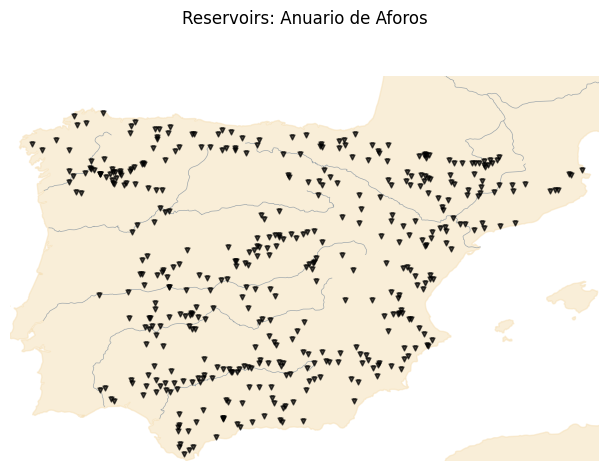

In [7]:
# identify water authorities
basins = {
    dir.stem: dir for dir in sorted(cfg.path_records.iterdir()) 
    if dir.is_dir() &  (dir.stem not in ['estaciones', 'GIS', 'timeseries'])
    }

# get dams from Anuario de Aforos
dams = []
for basin, path in tqdm(basins.items()):
    res = get_dams_anuario(
        path, 
        epsg=cfg.crs
        )
    res['basin'] = basin
    dams.append(res)
    print('No. reservoirs in {0:>13}:\t{1:>3}'.format(basin.title(), res.shape[0]))
    del res
dams = pd.concat(dams, axis=0)
dams.sort_index(axis=0, inplace=True)

# load mapping between dataset IDs
if file_map_datasets.is_file():
    # leer archivo
    with open(file_map_datasets, 'r') as file:
        map_datasets = yaml.safe_load(file)
    # añadir códigos
    keys = list(next(iter(map_datasets.values())).keys())
    cols = {key: f'id_{key.lower()}' for key in keys}
    for key, col in cols.items():
        dams[col] = dams.index.map({
            ID: dct[key] for ID, dct in map_datasets.items()
            })
    dams[list(cols.values())] = dams[list(cols.values())].astype('Int64')

# add reservoirs in Catalunya
dams_aca = gpd.read_file(path_aca / 'GIS' / 'dams_aca.geojson').set_index('id')
dams_aca.drop(10118, inplace=True) # E018 is in "Anuario"!!
print('No. reservoirs in {0:>13}:\t{1:>3}'.format('Catalunya', len(dams_aca)))
dams = pd.concat([dams, dams_aca], axis=0)
dams.sort_index(axis=0, inplace=True)

# add reservoirs in Andalucía
dams_hidrosur = gpd.read_file(path_hidrosur / 'GIS' / 'dams_hidrosur.geojson').set_index('id')
dams_hidrosur.drop(index=[6371, 6380], inplace=True) # already in "Anuario"!!
print('No. reservoirs in {0:>13}:\t{1:>3}'.format('Andalucía', len(dams_hidrosur)))
cols = dams_hidrosur.columns.intersection(dams.columns)
dams = pd.concat([dams, dams_hidrosur[cols]], axis=0)
dams.sort_index(axis=0, inplace=True)

# plot a map
plot_stations_map(
    dams.geometry, 
    extent=[-9.5, 3.5, 36, 44.5],
    marker='v',
    color='k',
    title=f'Reservoirs: Anuario de Aforos',
    # save=cfg.path_plots / 'dams.jpg'
)

print('\nTotal no. reservoirs:\t\t\t{0:>3}'.format(dams.shape[0]))
print('Total no. active reservoirs:\t\t{0:>3}'.format(dams.loc[dams.active == 1].shape[0]))

# export shapefile
file = cfg.path_gis / 'dams_anuario.geojson'
dams.to_file(file, driver='GeoJSON')
print(f'\nShapefile exported: {file}')

### MITECO

In [8]:
# load reservoirs from MITECO
dams_miteco = get_dams_miteco(
    cfg.path_records / 'estaciones' / 'Situac_2_Embalse_rev.csv',
    # min_area=cfg.area_min,
    # min_volume=cfg.volume_min,
)
print('No. reservoirs in MITECO:\t\t{0:>4}'.format(dams_miteco.shape[0]))

missing_ids = dams.index.difference(dams_miteco.index)
print('No. reservoirs missing in Miteco:\t{0:>4}'.format(len(missing_ids)))

# update attributes
# comment @casadoj: skip "catch_skm" due to large errors
dams = update_attributes(dams, dams_miteco.drop(columns=['catch_skm']), sort=True)

# check missing values
dams[dams.columns.intersection(key_attrs)].isnull().sum()

No. reservoirs in MITECO:		 390
No. reservoirs missing in Miteco:	  47


cap_mcm       38
catch_skm    400
elev_masl     60
dtype: int64

> **WARNING**. The reservoirs in Galicia Costa and Catalunya are missing in MITECO.

### National Inventory of Dams & Reservoirs

#### Reservoirs

In [9]:
# load reservoirs
reservoirs_idr = get_reservoirs_IDR(
    path_snczi / 'egis_embalse.shp',
    ids=dams['id_idr_res'],
    # min_area=cfg.area_min,
    # min_volume=cfg.volume_min
)
print(f'No. reservoirs in the inventory:\t{len(reservoirs_idr):>4}')

# compute surface area
reservoirs_idr['area_skm'] = reservoirs_idr.area * 1e-6 # km²

# set 'id' in _Anuario_ as index
reservoirs_idr = reset_index(reservoirs_idr, dams['id_idr_res'].dropna())
missing_ids = dams.index.difference(reservoirs_idr.index)
print('No. reservoirs missing:\t\t\t{0:>4}'.format(len(missing_ids)))

# update attributes
if dams.crs != reservoirs_idr.crs:
    reservoirs_idr = reservoirs_idr.to_crs(dams.crs)
dams = update_attributes(dams, reservoirs_idr)

# check missing values
print('\nMissing values:')
use_cols = [col for col in dams.columns if 'use' in col]
dams[dams.columns.intersection(key_attrs + use_cols)].isnull().sum()

No. reservoirs in the inventory:	 431
No. reservoirs missing:			   6

Missing values:


area_skm       6
cap_mcm        3
catch_skm    183
elev_masl     38
main_use      11
use_elec       6
use_fcon       6
use_ind        6
use_irri       6
use_live       6
use_mine       6
use_othr       6
use_supp       6
dtype: int64

#### Dams

In [10]:
# load dams
dams_idr = get_dams_IDR(
    path_snczi / 'egis_presa.shp',
    ids=dams['id_idr_dam'],
    # min_area=cfg.area_min,
    # min_volume=cfg.volume_min
).to_crs(dams.crs)
print(f'No. dams in the inventory:\t\t{len(dams_idr):>4}')

# set 'id' in _Anuario_ as index
dams_idr = reset_index(dams_idr, dams['id_idr_dam'].dropna())
missing_ids = dams.index.difference(dams_idr.index)
print('No. reservoirs missing:\t\t\t{0:>4}'.format(len(missing_ids)))

# update attributes
dams = update_attributes(dams, dams_idr)

# check missing values
print('\nMissing values:')
use_cols = [col for col in dams.columns if 'use' in col]
dams[dams.columns.intersection(key_attrs + use_cols)].isnull().sum()

No. dams in the inventory:		 429
No. reservoirs missing:			   8

Missing values:


area_skm       6
cap_mcm        3
catch_skm    175
elev_masl     38
main_use      11
use_elec       6
use_fcon       6
use_ind        6
use_irri       6
use_live       6
use_mine       6
use_othr       6
use_supp       6
users         26
dtype: int64

### Global Dam Watch

In a previous version, I truster more the GDW catchment area values than the Inventory, so these cells would go before the cells related to the Inventory. However, now I saw that the capacity values are better in the Inventory.

#### Reservoirs

In [11]:
# load reservoirs
reservoirs_gdw = gpd.read_file(path_gdw / 'GDW_reservoirs_v1_0.shp')
reservoirs_gdw.columns = reservoirs_gdw.columns.str.lower()
reservoirs_gdw.set_index('gdw_id', inplace=True)
reservoirs_gdw = reservoirs_gdw[reservoirs_gdw.country.str.lower().isin(['spain', 'portugal'])]
reservoirs_gdw = reservoirs_gdw.replace(-99, np.nan)
print(f'No. reservoirs in GDW:\t\t\t{len(reservoirs_gdw):>4}')

# reset index
reservoirs_gdw = reset_index(reservoirs_gdw, mapping=dams.id_gdw.dropna())
missing_ids = dams.index.difference(reservoirs_gdw.index)
print(f'No. reservoirs missing:\t\t\t{len(missing_ids):>4}')

# update attributes
use_cols = [col for col in reservoirs_gdw.columns if 'use' in col]
dams = update_attributes(dams, reservoirs_gdw[key_attrs + use_cols])

# check missing values
print('\nMissing values:')
dams[dams.columns.intersection(key_attrs + use_cols)].isnull().sum()

No. reservoirs in GDW:			 597
No. reservoirs missing:			  99

Missing values:


area_skm       6
cap_mcm        3
catch_skm     23
dam_hgt_m    193
elev_masl     14
main_use      11
use_elec       6
use_fcon       6
use_fish     437
use_irri       6
use_live       6
use_navi     437
use_othr       6
use_pcon     437
use_recr     435
use_supp       6
dtype: int64

#### Dams

In [12]:
# load dams
dams_gdw = gpd.read_file(path_gdw / 'GDW_barriers_v1_0.shp')
dams_gdw.columns = dams_gdw.columns.str.lower()
dams_gdw.set_index('gdw_id', inplace=True)
dams_gdw = dams_gdw[dams_gdw.country.str.lower().isin(['spain', 'portugal'])]
dams_gdw = dams_gdw.replace(-99, np.nan)
print(f'No. dams in GDW:\t\t\t{len(dams_gdw):>4}')

# reset index
dams_gdw = reset_index(dams_gdw, mapping=dams.id_gdw.dropna())
missing_ids = dams.index.difference(dams_gdw.index)
print(f'No. reservoirs missing:\t\t\t{len(missing_ids):>4}')

# update attributes
use_cols = [col for col in reservoirs_gdw.columns if 'use' in col]
dams = update_attributes(dams, dams_gdw[key_attrs + use_cols])

# check missing values
print('\nMissing values:')
dams[dams.columns.intersection(key_attrs + use_cols)].isnull().sum()

No. dams in GDW:			 723
No. reservoirs missing:			  91

Missing values:


area_skm       6
cap_mcm        3
catch_skm     18
dam_hgt_m    193
elev_masl     14
main_use      11
use_elec       6
use_fcon       6
use_fish     437
use_irri       6
use_live       6
use_navi     437
use_othr       6
use_pcon     437
use_recr     435
use_supp       6
dtype: int64

## Time series

### Reservoir operations

In [13]:
resops = {}

# Anuario de Aforos
for basin, path in tqdm(basins.items(), desc='basins'):
    ids = dams[dams.basin == basin].index.to_list()
    data = get_reservoir_series(
        path,
        id=ids,
        start=cfg.start,
        end=cfg.end,
        inflow=True,
        fill_value=np.nan
    )
    print('No. reservoirs in {0:<14}\t{1:>3} ({2:>3})'.format(basin.title()+ ':', len(data), len(ids)))
    resops.update(data)

# Catalunya
basin = 'CATALUÑA'
data = {}
ids = dams[dams.basin == basin].index.to_list()
for ID in ids:
    file = path_aca / 'timeseries' / 'reservoirs' / '{0}.parquet'.format(dams.loc[ID, 'id_saih'])
    if file.is_file():
        ts = pd.read_parquet(file)
        # compute inflows
        if {'storage', 'outflow'}.issubset(ts):
            ts['type'] = 2
            ts = compute_inflows(ts, fill_value=np.nan)
            ts.drop(columns='type', inplace=True)
        ts = ts.loc[cfg.start:cfg.end].asfreq('D')
        if not ts.empty:
            data[ID] = ts
    else:
        logger.info(f"{file} couldn't be found")
print('No. reservoirs in {0:<14}\t{1:>3} ({2:>3})'.format(basin.title()+ ':', len(data), len(ids)))
resops.update(data)

# Andalucía
basin = 'ANDALUCÍA'
data = {}
ids = dams[dams.basin == basin].index.to_list()
for ID in ids:
    file = path_hidrosur / 'timeseries' / 'reservoirs' / '{0}.parquet'.format(dams.loc[ID, 'id_saih'])
    if file.is_file():
        ts = pd.read_parquet(file)
        if ts.index.tz is not None:
            ts.index = ts.index.tz_localize(None)
        # compute inflows
        if {'storage', 'outflow'}.issubset(ts) and (not {'inflow'}.issubset(ts)):
            ts['type'] = 2
            ts = compute_inflows(ts, fill_value=np.nan)
            ts.drop(columns='type', inplace=True)
        ts = ts.loc[cfg.start:cfg.end].asfreq('D')
        if not ts.empty:
            data[ID] = ts
    else:
        logger.info(f"{file} couldn't be found")
print('No. reservoirs in {0:<14}\t{1:>3} ({2:>3})'.format(basin.title()+ ':', len(data), len(ids)))
resops.update(data)

print('\nTotal no. reservoirs with time series:\t{0:>3} ({1:>3})'.format(len(resops), len(dams)))

basins:   0%|          | 0/10 [00:00<?, ?it/s]

No. reservoirs in Cantabrico:   	 21 ( 22)
No. reservoirs in Duero:        	 31 ( 31)
No. reservoirs in Ebro:         	 93 ( 95)
No. reservoirs in Galicia Costa:	  8 (  8)
No. reservoirs in Guadalquivir: 	 62 ( 62)
No. reservoirs in Guadiana:     	 35 ( 35)
No. reservoirs in Jucar:        	 31 ( 35)
No. reservoirs in Miño-Sil:     	 34 ( 35)
No. reservoirs in Segura:       	 18 ( 18)
No. reservoirs in Tajo:         	 57 ( 57)
No. reservoirs in Cataluña:     	 12 ( 12)
No. reservoirs in Andalucía:    	 27 ( 27)

Total no. reservoirs with time series:	429 (437)


**Check quality of inflow estimation**

Here, I test the estimated inflow time series against the observed streamflow upstream and downstream some reservoirs in the Duero, for which I have identified gauges next to the reservoir

```Python
path_camels = Path('/home/casadoj/Data/CAMELS-ES/v1_2_0/preprocessing/timeseries/discharge')

with open('map_reservoirs_stations.yml', 'r') as file:
    map_stations = yaml.safe_load(file)

from typing import Union, Optional, List

def read_timeseries(
        path: Path,
        id: Union[int, List[int]],
        name: Optional[str] = None
):
    if isinstance(id, int):
        id = [id]
    ts = pd.concat(
        [pd.read_parquet(path / f'{stn}.parquet') for stn  in id],
        axis=1
    )
    ts.name = name
    ts.index.name = 'date'

    return ts
ID = 2032 # Riaño
ID = 2026 # Barrios de Luna
ID = 2030 # Juan Benet

ts = timeseries[ID]
capacity = reservoirs_egis.loc[reservoirs.loc[ID, 'id_egis'], 'NMN_CAPAC']
plot_resops(
    storage=ts.storage,
    inflow=ts.inflow,
    outflow=ts.outflow,
    capacity=capacity,
)

# get in/out-flow from river gauges
obs = pd.DataFrame({
    var: read_timeseries(
        path_camels,
        map_stations[ID][var]
    ).sum(axis=1) for var in ['inflow', 'outflow']
})
lw = .5
fig, axes = plt.subplots(nrows=2, figsize=(12, 8), sharex=True, sharey=True)

for ax, var in zip(axes, ['inflow', 'outflow']):
    ax.plot(ts[var], lw=lw, label='reservoir')
    ax.plot(obs[var], lw=lw, label='gauges')
    ax.set_ylabel(f'{var} (m³/s)')
    ax.legend()
```

### Evaporation

#### Evaporimeters

In [14]:
if evapo:
    # extract evaporimeters from Anuario de Aforos
    evaporimeters = []
    for basin in tqdm(basins):
        eva = get_evaporimeters(cfg.path_records / basin / 'estev.csv', epsg=cfg.crs)
        eva['basin'] = basin
        evaporimeters.append(eva)
        print('No. reservoirs in {0:>13}:\t\t{1:>3}'.format(basin.title(), eva.shape[0]))
        del eva
    evaporimeters = pd.concat(evaporimeters, axis=0)
    evaporimeters.sort_index(axis=0, inplace=True)

    # map
    plot_stations(
        evaporimeters.geometry, 
        extent=[-9.5, 3.5, 36, 44.5],
        # marker='v',
        # color='k',
        title=f'Evaporimeters: Anuario de Aforos',
        # save=cfg.path_plots / 'evaporimeters.jpg'
    )

    print('\nTotal no. evaporimeters:\t\t\t{0:>3}'.format(len(evaporimeters)))
    print('Total no. active evaporimeters:\t\t\t{0:>3}'.format((evaporimeters.active == 1).sum()))
    print('Total no. active evaporimeters in reservoirs:\t{0:>3}'.format(evaporimeters.id_ceh.notnull().sum()))

    # export
    evaporimeters.to_file(cfg.path_gis / 'evaporimeters.geojson', driver='GeoJSON')

    # keep only evaporimeters in reservoirs
    evaporimeters = evaporimeters[evaporimeters.id_ceh.notnull()]

#### Meteo time series

In [15]:
if evapo:
    # get meteorological time series
    meteo = {}
    for basin, path in tqdm(basins.items(), desc='basins'):
        ids = evaporimeters[evaporimeters.basin == basin].index.to_list()
        data = get_meteo_series(
            path,
            id=ids,
            start=cfg.start,
            end=cfg.end,
        )
        print('No. evaporimeters in {0:>13}:\t\t{1:>2}/{2:>2}'.format(basin.title(), len(data), len(ids)))
        meteo.update(data)

    # rename with reservoir ID
    meteo = {evaporimeters.loc[ID, 'id_ceh'].item(): ts for ID, ts in meteo.items()}

    print('Total no. evaporimeters with time series:\t{0:>2}/{1:>2}'.format(len(meteo), len(evaporimeters)))

    # update table of attributes
    evaporimeters = evaporimeters.reset_index().set_index('id_ceh')
    evaporimeters = evaporimeters.loc[meteo.keys()]
    meteo_vars = ['evap_piche', 'evap_pan']
    evaporimeters[meteo_vars] = 0
    for ID, ts in meteo.items():
        evaporimeters.loc[ID, meteo_vars] = [int(var in ts.columns) for var in meteo_vars]

    # remove stations without time series on any of the variables of interest
    mask = (evaporimeters[meteo_vars] == 0).all(axis=1)
    evaporimeters = evaporimeters[~mask]

    print(f'No. evaporimeters (out of {len(evaporimeters)}) with time series of a variable:')
    evaporimeters[meteo_vars].sum()
else:
    meteo = {}

```Python
ts = meteo[1406]

fig, ax = plt.subplots(nrows=3, figsize=(12, 12), sharex=True)

for var in ['piche', 'pan']:
    ax[0].plot(ts[f'evap_{var}'], label=var)
# ax[0].plot(ts.precip_total)
ax[0].set_ylabel('evaporation (mm)')
ax[0].legend()

for var in ['max', 'min']:
    ax[1].plot(ts[f'temp_{var}_avg'], label=var)
ax[1].set_ylabel('temperature (°C)')
ax[1].legend()

ax[2].plot(ts.wind_speed)
ax[2].set_ylabel('wind speed (km/h)');
```

## Select Reservoirs and Study Period

In [16]:
# Add boolean fields with available variables
# reservoirs = reservoirs.loc[resops.keys()]
resops_vars = ['level', 'storage', 'outflow', 'inflow']
dams[resops_vars ] = 0
for ID, ts in resops.items():
    dams.loc[ID, resops_vars ] = [int(var in ts.columns) for var in resops_vars]
mask_vars = dams[resops_vars].any(axis=1)
print('No. reservoirs with daily time series:\t\t\t{0}'.format(mask_vars.sum()))

# pre-select best period of data
periods = pd.concat([
    select_study_period(
        ts[ts.columns.intersection(resops_vars)], 
        ID,
        cfg.availability, 
        cfg.min_years, 
        mode='any'
    ) for ID, ts in resops.items()
], axis=0)
dams.loc[periods.index, ['start', 'end']] = periods.values

# compute no. years with daily time series
dams['years_daily'] = (dams.end - dams.start).astype('Int64')
mask_years = dams.years_daily >= cfg.min_years
print('No. reservoirs with at least {0} years of daily data:\t{1}'.format(cfg.min_years, mask_years.sum()))

# keep only reservoirs with catchment area
mask_catch = dams.catch_skm >= cfg.area_min
print(f'No. reservoirs with a catchment area at least {cfg.area_min} km²:\t{mask_catch.sum()}')

# keep only reservoirs with storage capacity
mask_cap = dams.cap_mcm >= cfg.volume_min
print(f'No. reservoirs with a storage capacity at least {cfg.volume_min} hm³:\t{mask_cap.sum()}')

# keep reservoirs in at least another dataset
mask_datasets = dams[['id_idr_res', 'id_idr_dam', 'id_gdw']].notnull().any(axis=1)

# select reservoirs
mask_dam = mask_vars & mask_years & mask_catch & mask_cap & mask_datasets
print('No. selected reservoirs:\t\t\t\t{0:>3}'.format(mask_dam.sum()))
print('\nNo. selected reservoirs with time series of a variable:')
dams[mask_dam][resops_vars].sum()

No. reservoirs with daily time series:			429
No. reservoirs with at least 4 years of daily data:	413
No. reservoirs with a catchment area at least 10 km²:	400
No. reservoirs with a storage capacity at least 1 hm³:	418
No. selected reservoirs:				374

No. selected reservoirs with time series of a variable:


level       37
storage    374
outflow    342
inflow     348
dtype: int64

> **Warning**. The total number of reservoirs does not match any of the variables!

## Export

### Dams & Reservoirs

In [17]:
# compute degree of disruptivity (m)
dams['dod_m'] = dams['cap_mcm'] / dams['catch_skm']

# check column types
use_cols = [col for col in dams.columns if ('use' in col) & (col not in ['users', 'main_use'])]
dams[use_cols] = dams[use_cols].astype(bool)

# export point shapefile
file_dams = cfg.path_gis / 'dams.geojson'
dams[mask_dam].to_file(file_dams, driver='GeoJSON')
print(f'{mask_dam.sum()} dams exported.')

# export polygon shapefile
file_reservoirs = cfg.path_gis / 'reservoirs.geojson'
polygons = reservoirs_idr.loc[dams[mask_dam].index.intersection(reservoirs_idr.index), 'geometry']
reservoirs = gpd.GeoDataFrame(
    dams[mask_dam].drop(columns=['geometry']),
    geometry=polygons,
    crs=reservoirs_idr.crs
)
reservoirs.to_file(cfg.path_gis / 'reservoirs.geojson', driver='GeoJSON')
print(f'{len(reservoirs)} reservoirs exported.')

374 dams exported.
374 reservoirs exported.


#### `basin-delineation`

This section creates the GeoJSON file required as input to locate the stations in the MERIT and EFAS grids.

> **¡PRECAUCIÓN!** La capa de embalses/presas del SNCZI contiene muchos más embalses que los del _Anuario de Aforos_. ¿Convendría localizar todos ellos en los MDT para calcular el grado de alteración de las estaciones de aforo en CAMELS-ES?

In [18]:
path = cfg.path_dataset / 'preprocessing' / 'basins'
path.mkdir(parents=True, exist_ok=True)
create_input_file(
    geometry=dams.loc[mask_dam, 'geometry'],
    area=dams.loc[mask_dam, 'catch_skm'],
    file=path / 'dams.geojson'
)

### Time series

In [19]:
# export reservoir operations
path_ts = cfg.path_dataset / 'preprocessing' / 'timeseries' / 'resops'
path_ts.mkdir(parents=True, exist_ok=True)
for ID in tqdm(dams[mask_dam].index, desc='reservoirs'):
    ts = resops[ID]
    cols = ts.columns.intersection(resops_vars + ['quality'])
    start, end = ts.first_valid_index(), ts.last_valid_index()
    # start, end = reservoirs.loc[ID, ['inicio', 'fin']]

    if evapo is True:
        if ID in meteo:
            # extract monthly time series
            ts_meteo = meteo[ID].copy()
            cols_meteo = ts_meteo.columns.intersection(meteo_vars)

            # resample to daily time series
            ts_meteo_daily = upsample_to_daily(ts_meteo[cols_meteo])

            # concatenate
            ts = pd.concat([ts, ts_meteo_daily], axis=1)

    # export
    ts.loc[start:end, cols].to_parquet(path_ts / f'{ID}.parquet')

reservoirs:   0%|          | 0/374 [00:00<?, ?it/s]